In [2]:
import pandas as pd

data = pd.read_csv("reviews1.csv")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12495 entries, 0 to 12494
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              12495 non-null  str  
 1   userName              12495 non-null  str  
 2   userImage             12495 non-null  str  
 3   content               12495 non-null  str  
 4   score                 12495 non-null  int64
 5   thumbsUpCount         12495 non-null  int64
 6   reviewCreatedVersion  10333 non-null  str  
 7   at                    12495 non-null  str  
 8   replyContent          5818 non-null   str  
 9   repliedAt             5818 non-null   str  
 10  sortOrder             12495 non-null  str  
 11  appId                 12495 non-null  str  
dtypes: int64(2), str(10)
memory usage: 1.1 MB


In [3]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 1.6 MB/s eta 0:00:08
     --- ------------------------------------ 1.0/12.8 MB 1.8 MB/s eta 0:00:07
     ------ --------------------------------- 2.1/12.8 MB 2.4 MB/s eta 0:00:05
     ----------- ---------------------------- 3.7/12.8 MB 3.5 MB/s eta 0:00:03
     ---------------- ----------------------- 5.2/12.8 MB 4.2 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 4.7 MB/s eta 0:00:02
     -------------------------- ------------- 8.4/12.8 MB 5.1 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 5.3 MB/s eta 0:00:01
     ------------------------------------ --- 11.5/12.8 MB 5.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 5.6 MB/s  0:

In [4]:
# Takes ~2 mins to run

import re
import spacy


# Spacy - trained pipeline package for
# en - english
# core - vocabulary, syntax, entities
# web - trained on web data (blogs, news and comments)
# sm - small size for speed, uses context sensitive tensors 
nlp = spacy.load("en_core_web_sm")


data = data[['content', 'score', 'at', 'appId']].copy()


# Dropping duplicates to avoid model memorization
data.drop_duplicates(subset=['content'], inplace = True)


# Removing any review with length < 5, to reduce noise and keep meaningful data
# Remaining 10330 rows with meaningful, removed 1477 
data = data[data['content'].str.split().str.len() >= 5].reset_index(drop=True)


def clean_text(text):
    text = text.lower()

    # Removing markdown email links 
    text = re.sub(r'\[.*?\]\(mailto:.?\)', '', text)

    # Removing plain emails
    text = re.sub(r'\S+@\S+', '', text)

    # Removing URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Removing HTML tags 
    text = re.sub(r'<.*?>', '', text)

    # Normalizing emojis as punctutaion (space here)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Removing special characters (keeping apostrophes for contractions, eg: "don't")
    text = re.sub(r"[^a-z0-9\s']", ' ', text)

    # Normalizing whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text



# Using apply can make it slow for millions of rows, but okay for thousands  
data['content_clean'] = data['content'].apply(clean_text)


APP_NAME_TOKENS = {
    'anydo', 'todoist', 'task', 'habitica','forestapp' ,'forestapp', 'habitbull',
    'todos', 'timetune', 'bizcal', 'planner', 'calclock', 'habitnow', 'liferpgtasks', 'artfulagenda'
}

# Removing stopwords
DOMAIN_STOPWORDS = {
    'app', 'apps', 'please', 'thanks', 'thank', 'hi', 'hello', 'use',
    'used', 'using', 'get' , 'got', 'would', 'could', 'update', 'updated', 
    'version', 'phone', 'day', 'time', 'list', 'tap' ,'open' ,'show'
}

DOMAIN_STOPWORDS = DOMAIN_STOPWORDS | APP_NAME_TOKENS


def lemmatize(text):
    doc = nlp(text)

    # lemma_ reduces words to dictionary from; 'running','ran','runs' - 'run', 'better' - 'good'
    # .is_stop : identifies common words - this, is, at....
    # .is_alpha : identifies standard words and removes numbers, puncutations, emojis, mixed strings... 
    tokens =[
        token.lemma_ for token in doc  
        if not token.is_stop
        and token.is_alpha
        and len(token.text) > 2 # ignores very short tokens 
        and token.lemma_ not in DOMAIN_STOPWORDS 
    ] 

    return ' '.join(tokens)


data['content_processed'] = data['content_clean'].apply(lemmatize)

In [5]:
# Filtering length after lemmatization
# Since about ~800 tokens each are of length 3 and 4 its removed to retain meaning
data = data[data['content_processed'].str.split().str.len() >= 5].reset_index(drop=True)

print(f"Final dataset size: {len(data)}")
print(data[['content', 'content_processed']].head(10))

Final dataset size: 7824
                                             content  \
0  Very costly for the premium version (approx In...   
1  Used to keep me organized, but all the 2020 UP...   
2  It has changed how I viewed my different lists...   
3  I'm only looking for a grocery list app but ev...   
4  Reset my free trial, new phone I'd like to see...   
5  I complain about not crashes and it was immedi...   
6  Constant crashing. After reading all the negat...   
7  Widgets are useless because they always show a...   
8  Update October 2020: new update deleted all of...   
9  Spams notifications of how many tasks other us...   

                                   content_processed  
0  costly premium approx indian rupee year well d...  
1  organize mess thing leave enuf guess techie fe...  
2             change view different jumble find need  
3  look grocery away find way certain reopen eta ...  
4                     reset free trial new like well  
5  complain crash immediatel

In [6]:
# Checking token length distribution post-processing
lengths = data['content_processed'].str.split().str.len()
print(lengths.describe())
print(lengths.value_counts().sort_index().head(10))

count    7824.000000
mean       14.680215
std        10.446799
min         5.000000
25%         7.000000
50%        11.000000
75%        19.000000
max       263.000000
Name: content_processed, dtype: float64
content_processed
5     740
6     731
7     617
8     553
9     463
10    439
11    386
12    369
13    300
14    285
Name: count, dtype: int64


In [7]:
# Since there are about 263 tokens(max), it needs to be capped, sentence transformers have 256-512 token limit,
# Extremely long reviews get truncated at the tail and lose meaning.

data['content_processed'] = data['content_processed'].apply(
    lambda x: ' '.join(x.split()[:100])
)

lengths = data['content_processed'].str.split().str.len()
print(f"Final row count: {len(data)}")
print(f"Min tokens: {lengths.min()}")
print(f"Reviews with < 5 tokens: {(lengths < 5).sum()}")
print(f"Max tokens: {lengths.max()}")

Final row count: 7824
Min tokens: 5
Reviews with < 5 tokens: 0
Max tokens: 100


Using Sentence Transfomers instead of TF-iDF for capturing semantic meaning.

Using model - all-MiniLm-L6-v2:

This model has fixed size vectors of either 384 or 768 dimensions.

Given an input string, st model converts it to a vector of size 384: 

    Close vectors == similiar semantic meaning
    Far vectors == dissimilar semantic meaning
    
TF-IDF treats "can't login" and "unable to sign in" as completely different. The sentence transformer knows they mean the same thing.


In [25]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch

# Using GPU for quicker execution
# ~37s using GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('all-MiniLm-L6-v2', device = device)

# using cleaned test, instead of preprocessed, as preprocessed text looses too much meaning when passed to sentence transformers    
embeddings = model.encode(
    data['content_clean'].tolist(), 
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Embeddings shape: {embeddings.shape}")

# Saving to avoid recomputing
np.save('embeddings.npy', embeddings)
print("Saved!")

Batches: 100%|██████████| 123/123 [00:02<00:00, 44.01it/s]

Embeddings shape: (7824, 384)
Saved!


In [26]:
# Verification using cosine similarity

from sklearn.metrics.pairwise import cosine_similarity

# Picking 3 pairs manually from data
# Pair A: two reviews that should be SIMIIAR 
# Pair B: two reviews that should be DIFFERENT

# Reviews about price 
pricing_idx = data[data['content_clean'].str.contains('costly|expensive|price|rupee|refund')].index[:2].tolist()

# Reviews about crashes/bugs
crash_idx = data[data['content_clean'].str.contains('crash|freeze|bug|error')].index[:2].tolist()



# Comparison
print("===SIMILAR PAIR (both pricing)===")
print("A:", data['content_clean'].iloc[pricing_idx[0]])
print("B:", data['content_clean'].iloc[pricing_idx[1]])
sim = cosine_similarity([embeddings[pricing_idx[0]]], [embeddings[pricing_idx[1]]])[0][0]
print(f"Cosine similarity: {sim:.4f}")

print("\n=== DIFFERENT PAIR (pricing vs crash) ===")
print("A:", data['content_clean'].iloc[pricing_idx[0]])
print("B:", data['content_clean'].iloc[crash_idx[0]])
sim2 = cosine_similarity([embeddings[pricing_idx[0]]], [embeddings[crash_idx[0]]])[0][0]
print(f"Cosine similarity: {sim2:.4f}")

print("\n=== RANDOM PAIR (should be somewhere in between) ===")
sim3 = cosine_similarity([embeddings[0]], [embeddings[100]])[0][0]
print(f"Cosine similarity: {sim3:.4f}")

===SIMILAR PAIR (both pricing)===
A: very costly for the premium version approx indian rupees 910 per year better to download the premium version of this app from apkmos website and use it microsoft to do list app is far more better
B: expensive paywall preventing access to features in wanting to try out
Cosine similarity: 0.3130

=== DIFFERENT PAIR (pricing vs crash) ===
A: very costly for the premium version approx indian rupees 910 per year better to download the premium version of this app from apkmos website and use it microsoft to do list app is far more better
B: i complain about not crashes and it was immediately fixed good job now the crashes have returned i really need it fixed because i need to change apps otherwise i followed your instructions on deleting the data etc but it just now crashed again i am a patient person and i have used any do for years but let's try one more time and then i will have to find another app it crashed again
Cosine similarity: 0.2617

=== RANDOM 

In [27]:
# Find these manually in your df and note their indices
# Look for reviews that are almost paraphrases of each other

# Example targets to search for:
print(data[data['content_clean'].str.contains('sync')][['content_clean']].head(5))
print(data[data['content_clean'].str.contains('widget')][['content_clean']].head(5))
print(data[data['content_clean'].str.contains('notification')][['content_clean']].head(5))

                                         content_clean
6    constant crashing after reading all the negati...
16   i was about to pay for this app when i noticed...
31   frustrating apparently its meant to sync groce...
59   it syncs everything terrible you have to get t...
100  looks like a pretty good app but it doesn't sy...
                                         content_clean
7    widgets are useless because they always show a...
12   shows tasks assigned to others in widget a maj...
23   i have tried i installing this on two separate...
107  no grocery widget ridiculous the task widget i...
126  i found this app difficult to organize in a wa...
                                        content_clean
9   spams notifications of how many tasks other us...
11  they recently started sending spammy notificat...
20  uninstalled it as soon as it started sending m...
49  bring back my money why your system stolen my ...
57  useless app set up 8 reminders during a course...


In [28]:
sync_idx = [6, 16, 31, 59, 100]
widget_idx = [7, 12, 23, 107, 126]
notification_idx = [9, 11, 20, 49, 57]

print("SYNC vs SYNC:")
s1 = cosine_similarity([embeddings[sync_idx[0]]], [embeddings[sync_idx[1]]])[0][0]
print(f"{s1:.4f}")

print("SYNC vs WIDGET:")
s2 = cosine_similarity([embeddings[sync_idx[0]]],[embeddings[widget_idx[0]]])[0][0]
print(f"{s2:.4f}")

print("SYNC vs CRASH:")
s3 = cosine_similarity([embeddings[sync_idx[0]]],[embeddings[crash_idx[0]]])[0][0]
print(f"{s3:.4f}")

print("WIDGET vs WIDGET:")
s4 = cosine_similarity([embeddings[widget_idx[0]]],[embeddings[widget_idx[1]]])[0][0]
print(f"{s4:.4f}")



SYNC vs SYNC:
0.4811
SYNC vs WIDGET:
0.1369
SYNC vs CRASH:
0.7104
WIDGET vs WIDGET:
0.6208


Here the SYNC and CRASH embeddings are showing high similarity, but for the current use case; to identify customer pain points, this fits well. The sentence transformer identifies the negative emotion from the complaints and groups them closer, hence the similiarity.

In [29]:
# Structural sanity check

print("NaNs: ", np.isnan(embeddings).sum())
print("Infs: ", np.isinf(embeddings).sum())

norms = np.linalg.norm(embeddings, axis=1)

print(f"Norm mean: {norms.mean():.4f}, std: {norms.std():.4f}")


NaNs:  0
Infs:  0
Norm mean: 1.0000, std: 0.0000


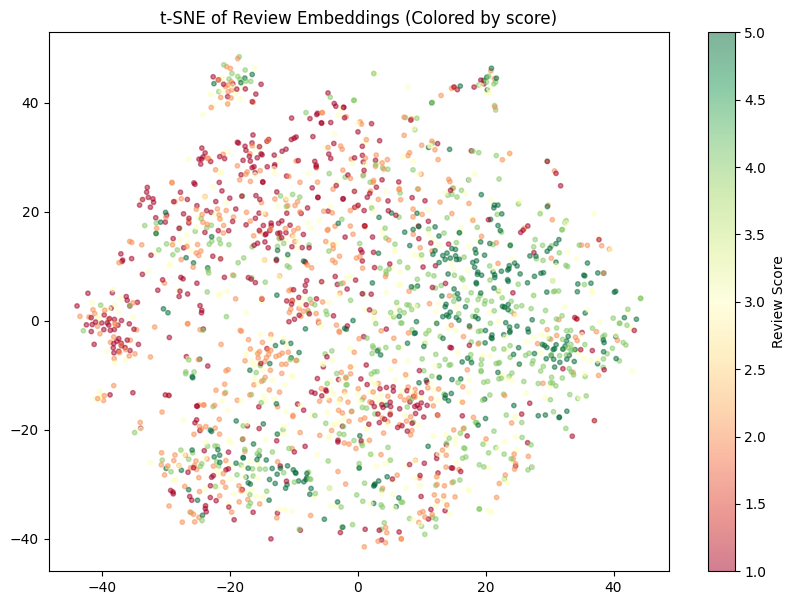

In [30]:
# Loose T-SNE (sample)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Using 2k subsample instead of entire 7k for speed
sample_idx = np.random.choice(len(embeddings), 2000, replace=False)
sample_embeddings = embeddings[sample_idx]
sample_scores = data['score'].iloc[sample_idx].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(sample_embeddings)

plt.figure(figsize=(10,7))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=sample_scores, cmap='RdYlGn', alpha=0.5, s=10)

plt.colorbar(scatter, label='Review Score')
plt.title('t-SNE of Review Embeddings (Colored by score)')
plt.savefig('tsne_phase2.png', dpi=75)
plt.show()

In [24]:
assert len(data) == embeddings.shape[0]

data.to_csv('reviews_preprocessed.csv', index=False)
print("Reviews saved!")

Reviews saved!


- Dataset:        7,824 reviews (15 productivity apps)
- Embedding model: all-MiniLM-L6-v2
- Embedding shape: (7824, 384)
- Input text:     content_clean (not lemmatized, preserves grammatical context)
- Key finding:    Embeddings strongly encode sentiment; topic separation is present but loose at this stage (expected). Autoencoder compression expected to sharpen structure.
- Saved to:       embeddings.npy
